<a href="https://colab.research.google.com/github/lalithanjalivavilapalli2109/FDS-DATASET/blob/main/automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("Automobile_data.csv")

print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


First 5 Records
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compr

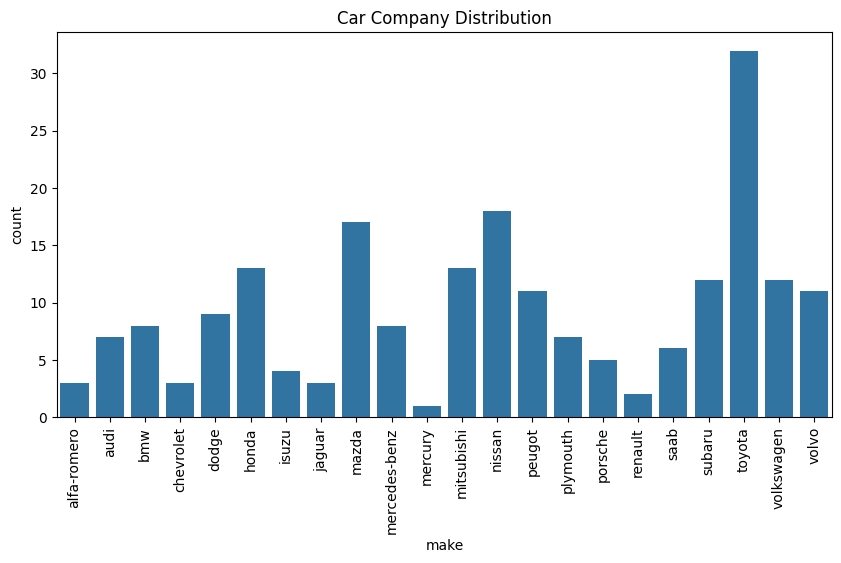

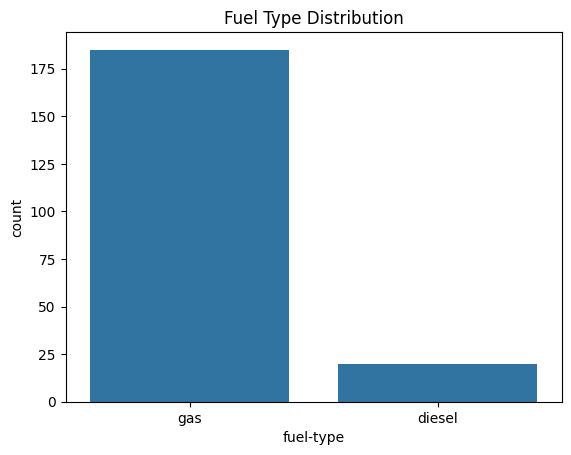

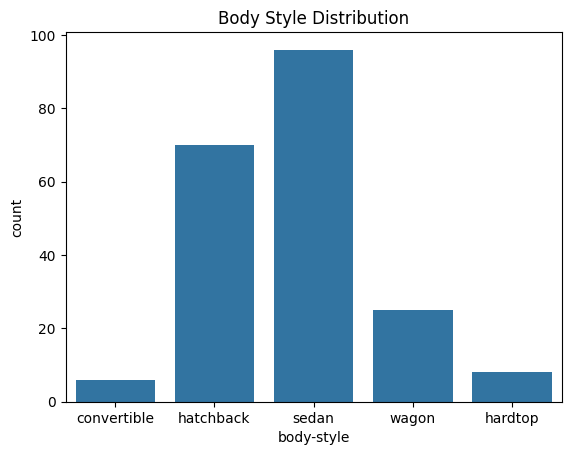

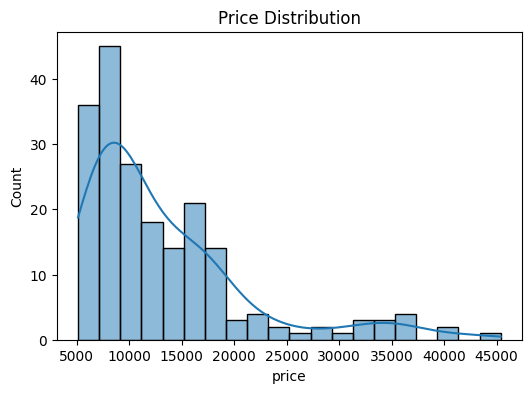

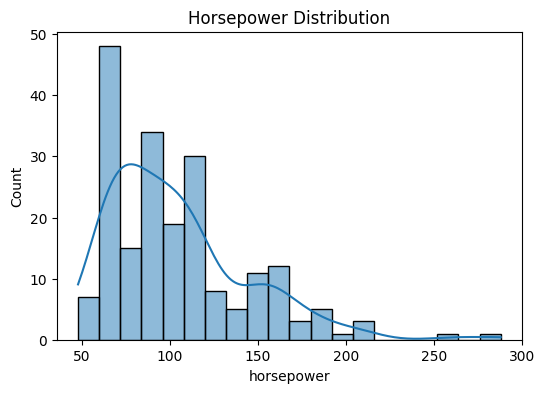

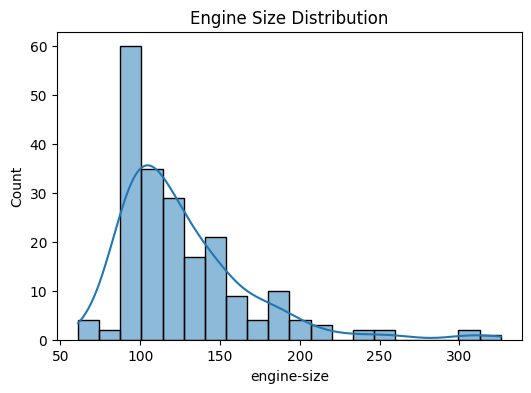

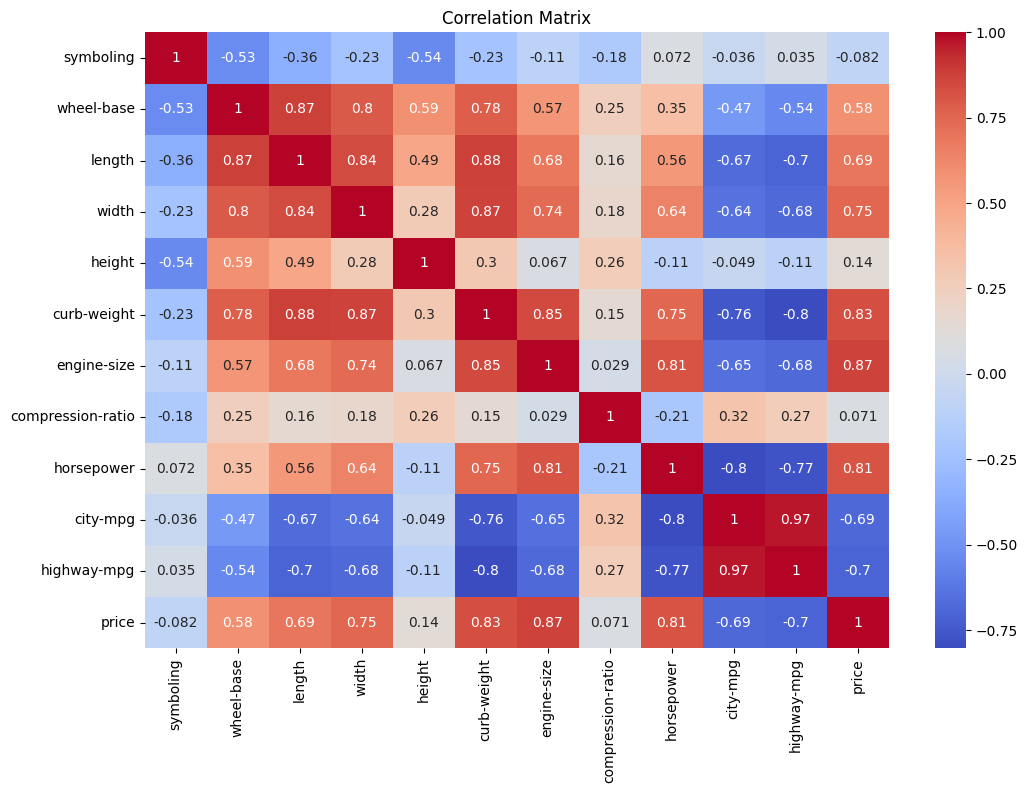

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset
df = pd.read_csv("Automobile_data.csv")

# Replace '?' with NaN
df.replace("?", pd.NA, inplace=True)

# Convert numerical columns
numeric_cols = [
    'price', 'horsepower', 'engine-size',
    'city-mpg', 'highway-mpg', 'wheel-base'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Car company distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='make', data=df)
plt.xticks(rotation=90)
plt.title("Car Company Distribution")
plt.show()

# Fuel type distribution
sns.countplot(x='fuel-type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

# Body style distribution
sns.countplot(x='body-style', data=df)
plt.title("Body Style Distribution")
plt.show()

# Price distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

# Horsepower distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['horsepower'], bins=20, kde=True)
plt.title("Horsepower Distribution")
plt.show()

# Engine size distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['engine-size'], bins=20, kde=True)
plt.title("Engine Size Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
print("\nNumeric Attributes")
numeric = df.select_dtypes(include=['int64', 'float64']).columns
print(list(numeric))

print("\nNominal Attributes")
nominal = [
    'make',
    'fuel-type',
    'body-style',
    'drive-wheels',
    'engine-type'
]

print(nominal)

print("\nBinary Attributes")
binary = ['aspiration']

print(binary)


Numeric Attributes
['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'compression-ratio', 'horsepower', 'city-mpg', 'highway-mpg', 'price']

Nominal Attributes
['make', 'fuel-type', 'body-style', 'drive-wheels', 'engine-type']

Binary Attributes
['aspiration']


In [ ]:
make = df['make']
body_style = df['body-style']

count = 0
total = 0

for m, b in zip(make, body_style):

    if pd.isna(m) or pd.isna(b):
        continue

    total += 1

    if m != b:
        count += 1

dissimilarity = count / total

print("\nNominal Attribute Dissimilarity")
print("Make vs Body Style =", dissimilarity)


Nominal Attribute Dissimilarity
Make vs Body Style = 1.0


In [ ]:
# Remove Missing Values

temp = df[['price', 'horsepower']].dropna()

price1 = temp.iloc[0]['price']
horsepower1 = temp.iloc[0]['horsepower']

price2 = temp.iloc[1]['price']
horsepower2 = temp.iloc[1]['horsepower']

distance = np.sqrt((price1 - price2)**2 +
                   (horsepower1 - horsepower2)**2)

print("\nEuclidean Distance")
print(distance)


Euclidean Distance
3005.0


In [ ]:
manhattan = abs(price1 - price2) + abs(horsepower1 - horsepower2)

print("\nManhattan Distance")
print(manhattan)


Manhattan Distance
3005.0


In [ ]:
minkowski = (
    (abs(price1 - price2) ** 3) +
    (abs(horsepower1 - horsepower2) ** 3)
) ** (1 / 3)

print("\nMinkowski Distance")
print(minkowski)


Minkowski Distance
3004.9999999999986


In [ ]:
A = np.array([price1, horsepower1])
B = np.array([price2, horsepower2])

cosine_similarity = np.dot(A, B) / (
    np.linalg.norm(A) * np.linalg.norm(B)
)

cosine_dissimilarity = 1 - cosine_similarity

print("\nCosine Dissimilarity")
print(cosine_dissimilarity)


Cosine Dissimilarity
1.1218697986148385e-06
